In [1]:
#load the processed data with the distributions.
#create data frame

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path("..").resolve()
processed_path = root / "data" / "processed"
raw_path = root / "data" / "raw"
test_path = raw_path / "2025"
dates_path = raw_path / "dates"

# load final distribution params from each processed (training) CSV
# for each (symbol, dte, bucket), keep the last valid (mean, std)
dist_lookup = {}

for f in sorted(processed_path.glob("*_*_*.csv")):
    parts = f.stem.rsplit("_", 2)
    symbol, dte, bucket = parts[0], int(parts[1]), int(parts[2])
    df = pd.read_csv(f, usecols=["dist_mean", "dist_std"])
    valid = df.dropna(subset=["dist_mean", "dist_std"])
    if not valid.empty:
        dist_lookup[(symbol, dte, bucket)] = (valid["dist_mean"].iloc[-1], valid["dist_std"].iloc[-1])

print(f"Loaded distributions for {len(dist_lookup)} (symbol, dte, bucket) bins")

# load trading calendar and expiry dates for DTE computation
trading_cal = pd.read_csv(dates_path / "trading_calendar.csv", parse_dates=["date"])
expiry_dates_df = pd.read_csv(dates_path / "expiry_dates.csv", parse_dates=["expiry_date"])
trading_days_sorted = sorted(set(trading_cal["date"]))
expiry_list = sorted(expiry_dates_df["expiry_date"])

buckets = ["9:15:00","10:00:00","11:00:00","12:00:00","13:00:00","14:00:00","15:00:00"]


def find_first_gte(arr, target):
    """Binary search: index of first element >= target."""
    lo, hi = 0, len(arr)
    while lo < hi:
        mid = (lo + hi) // 2
        if arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid
    return lo


def find_exact(arr, target):
    """Binary search for exact match. Returns index or None."""
    idx = find_first_gte(arr, target)
    if idx < len(arr) and arr[idx] == target:
        return idx
    return None


def get_dte(day_val):
    cur = pd.Timestamp(str(day_val))
    ei = find_first_gte(expiry_list, cur)
    if ei >= len(expiry_list):
        return np.nan
    expiry = expiry_list[ei]
    idx_cur = find_exact(trading_days_sorted, cur)
    idx_exp = find_exact(trading_days_sorted, expiry)
    if idx_cur is None or idx_exp is None:
        return np.nan
    return idx_exp - idx_cur


def get_bucket(time_str):
    t = pd.Timedelta(time_str)
    bucket_td = [pd.Timedelta(b) for b in buckets]
    for i in range(len(bucket_td) - 1, -1, -1):
        if t >= bucket_td[i]:
            return i
    return 0

Loaded distributions for 336 (symbol, dte, bucket) bins


In [2]:
symbols = ["BAJFINANCE", "RELIANCE"]
out_thresh = 2.0
rev_thresh = 1.0

In [3]:

columns_fut_25 = ["day", "time", "fut_ltp", "fut_ltq", "oi_fut"]
columns_eq_25 = ["day", "time", "ltp", "ltq", "oi"]
months = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"]

plot_data = {}

for sym in symbols:
    all_data = []
    df_eq = pd.read_csv(test_path / f"{sym}.csv", header=None, names=columns_eq_25)
    df_eq["timestamp"] = pd.to_datetime(df_eq["day"].astype(str) + " " + df_eq["time"])

    for mon in months:
        fut_file = test_path / f"{sym}25{mon}FUT.csv"
        if not fut_file.exists():
            continue
        df_fut = pd.read_csv(fut_file, header=None, names=columns_fut_25)
        df_fut["timestamp"] = pd.to_datetime(df_fut["day"].astype(str) + " " + df_fut["time"])
        df = pd.merge_asof(df_fut, df_eq, on="timestamp", direction="backward", suffixes=("_fut", "_eq"))
        df = df.dropna(subset=["ltp"])

        df["spread"] = ((df["fut_ltp"] - df["ltp"]) / df["ltp"]) * 100
        df["dte"] = df["day_fut"].apply(get_dte)
        df["bucket"] = df["time_fut"].apply(get_bucket)
        df = df.dropna(subset=["dte"])

        df["dist_mean"] = np.nan
        df["dist_std"] = np.nan
        for (d, b), idx in df.groupby(["dte", "bucket"]).groups.items():
            dist = dist_lookup.get((sym, int(d), int(b)))
            if dist is None:
                continue
            df.loc[idx, "dist_mean"] = dist[0]
            df.loc[idx, "dist_std"] = dist[1]

        df["z_score"] = (df["spread"] - df["dist_mean"]) / df["dist_std"]
        df["contract"] = mon
        all_data.append(df[["timestamp", "spread", "z_score", "dist_mean", "dist_std", "contract", "ltp"]])
        print(f"  {sym}25{mon}FUT: {len(df)} ticks")

    if all_data:
        plot_data[sym] = pd.concat(all_data).sort_values("timestamp").reset_index(drop=True)
        print(f"{sym}: {len(plot_data[sym])} total ticks")

  BAJFINANCE25JANFUT: 122138 ticks
  BAJFINANCE25FEBFUT: 162991 ticks
  BAJFINANCE25MARFUT: 149805 ticks
  BAJFINANCE25APRFUT: 146218 ticks
  BAJFINANCE25MAYFUT: 170398 ticks
  BAJFINANCE25JUNFUT: 115120 ticks
  BAJFINANCE25JULFUT: 132151 ticks
  BAJFINANCE25AUGFUT: 144009 ticks
  BAJFINANCE25SEPFUT: 142200 ticks
  BAJFINANCE25OCTFUT: 127107 ticks
  BAJFINANCE25NOVFUT: 133000 ticks
  BAJFINANCE25DECFUT: 118687 ticks
BAJFINANCE: 1663824 total ticks
  RELIANCE25JANFUT: 233394 ticks
  RELIANCE25FEBFUT: 269267 ticks
  RELIANCE25MARFUT: 271481 ticks
  RELIANCE25APRFUT: 252987 ticks
  RELIANCE25MAYFUT: 307724 ticks
  RELIANCE25JUNFUT: 235398 ticks
  RELIANCE25JULFUT: 248222 ticks
  RELIANCE25AUGFUT: 237823 ticks
  RELIANCE25SEPFUT: 257378 ticks
  RELIANCE25OCTFUT: 230014 ticks
  RELIANCE25NOVFUT: 223193 ticks
  RELIANCE25DECFUT: 223510 ticks
RELIANCE: 2990391 total ticks


Dickey–Fuller test and the Phillips–Perron test : examining price stationarity

Any adaptations for current framework?


have a dataframe of all first detections.
e.g the workflow looks something like
1. see outlier(based on corresponding distribuition at given time)
2. log zscore, cash price, spread, volume, oi, bid ask data, time.
3. track event till closure/end of session. log the type of closure, z at closure.  also track the max/min value of z, the time of max/min, spread at that value, as well as cash price, volume, contract(which month expiry)
4. append all this information to the earlier log
5. append the whole log to the dataframe. also keep it as a sort of map with the key being (dte,time bucket) information

6. track the evolution of the outliers and superpose on the above graph

7. another option : plot just the equity along with the above graph (edit the above cell, write a separate function for the plot and call it, cleaner)

while plotting for a given month, do the following-
1. set outlier threshold and reversion threshold (crossing outthresh+revthresh -> divergence, crossing outthresh-revthresh -> reversion, else continuation. hard rule)
2. read processed/symbol_bucket_dte.csv for all symbols and buckets and dte for all 3 contracts(separate plots for each contract)
3. read the distribution parameters from the csv and for each bucket draw the +/- outthress, outthresh+/-revthresh  lines. these should change for each bucket.
4. plot the spreads by reading the live values from the csvs and stitch together a dataframe.  ( check the dates properly) 
5. for finding outliers, do a binary search. additional condition is the number of ticks in the outlier zone(set a parameter, set to 3 for now). this is the min amount of time it should spend in the outlier zone
6. after this, do a binary search to find the first instance it crosses the rev/div threshold. if nothing found return end of session.
7. once you have these two limits set, find the spread and the time of the extremum spread.
8. mark all three points on the graph.
9. if the first instance of crossing the threshold is not end of session, repeat the process on the (first instance,end of session) till all points are exhausted, you can use a priority queue for this if you want. 
10. all these parameters should be logged as in the instructions in the cells.
points 5,6,7,9 should be taken care of by the track function.
points 2,3 : read processed function
points 4,8 : plot function (keep it simple for now, no plotly needed)
explain the code line by line and how each functionality is added. 


In [4]:
# ---------- read_processed ----------
# Load the full per-symbol processed frame (all dte/bucket bins concatenated).
# Every row already carries timestamp, spread, dte, bucket, contract,
# dist_mean, dist_std, ltp (cash) and the bid/ask columns -- no raw I/O or
# re-merge needed downstream. Cached so re-calls are instant.

_processed_cache = {}

def read_processed(symbol):
    if symbol in _processed_cache:
        return _processed_cache[symbol]
    frames = []
    for f in sorted(processed_path.glob(f"{symbol}_*_*.csv")):
        frames.append(pd.read_csv(f, parse_dates=["timestamp"]))
    full = (pd.concat(frames, ignore_index=True)
              .sort_values("timestamp")
              .reset_index(drop=True))
    _processed_cache[symbol] = full
    print(f"read_processed({symbol}): {len(full):,} rows from {len(frames)} bins")
    return full


In [5]:
# ---------- contract helpers + processed slicer ----------
# No raw-file I/O. Filter the per-symbol processed frame to one contract in one
# (year, month) observation window -- or one single session when `day` is given.

def get_contracts_for(year, month_str):
    """(2025, 'JAN') -> ['25JAN', '25FEB', '25MAR']. Wraps across year-end."""
    mi = months.index(month_str)
    y2 = year % 100
    return [f"{(y2 + (mi + i) // 12):02d}{months[(mi + i) % 12]}" for i in range(3)]


def _resolve_day(day, year, m_num):
    """Accept day-of-month (23) or full YYYYMMDD (20240123); return YYYYMMDD int."""
    d = int(day)
    return d if d >= 10000 else year * 10000 + m_num * 100 + d


def slice_processed(full, contract_tok, year, month_str, day=None):
    """Return rows for one contract in (year, month_str); narrowed to `day`
    if given. day_fut in processed is an int YYYYMMDD."""
    month_tag = contract_tok[2:]                         # '25FEB' -> 'FEB'
    m_num     = months.index(month_str) + 1
    mask = ((full["contract"] == month_tag)
            & (full["timestamp"].dt.year  == year)
            & (full["timestamp"].dt.month == m_num))
    if day is not None:
        mask &= full["day_fut"].astype(int) == _resolve_day(day, year, m_num)
    sel = full[mask].copy()
    if sel.empty:
        return sel

    sel["z_score"] = (sel["spread"] - sel["dist_mean"]) / sel["dist_std"]
    sel["day_fut"] = sel["day_fut"].astype(int)
    sel["dte"]     = sel["dte"].astype(int)
    sel["bucket"]  = sel["bucket"].astype(int)
    return sel.reset_index(drop=True)


In [6]:
# ---------- track ----------
# Task points 5, 6, 7, 9. One session at a time.
#
# Detection  : first run of >= min_ticks consecutive ticks with |z| > out_thresh.
# Resolution : first tick that CROSSES the divergence or reversion line.
#              A "crossing" requires a transition -- z was on the non-triggered
#              side at tick k-1 and on the triggered side at tick k. If z
#              starts already past the divergence line at detection (sustained
#              extreme spread from open), there is no crossing -> continuation.
# Re-entry   : after a resolution, next scan starts only once |z| <= out_thresh.

import heapq


def _first_run_start(is_out, lo, hi, k):
    seg = is_out[lo:hi + 1].astype(np.int32)
    if seg.size < k:
        return None
    cs  = np.concatenate(([0], np.cumsum(seg)))
    win = cs[k:] - cs[:-k]
    hits = np.where(win == k)[0]
    if hits.size == 0:
        return None
    return lo + int(hits[0])


def _find_resolution(z, start, hi, out_thresh, rev_thresh, side):
    """First true CROSSING of the div or rev line after `start`. Returns
    (idx, klass) where klass in {'divergence', 'reversion', 'continuation'}.
    Continuation -> idx = hi (end of session)."""
    if start >= hi:
        return hi, "continuation"
    div = out_thresh + rev_thresh
    rev = out_thresh - rev_thresh
    sub = z[start:hi + 1]                         # include z[start] to detect a
                                                  # crossing between start and start+1
    if side == 1:
        div_in = sub >= div
        rev_in = sub <= rev
    else:
        div_in = sub <= -div
        rev_in = sub >= -rev

    # A crossing at offset k (in sub) means sub[k-1] was outside the zone and
    # sub[k] is inside. Indexed by k in [1, len(sub)-1] -> array of len(sub)-1.
    cross_div = (~div_in[:-1]) & div_in[1:]
    cross_rev = (~rev_in[:-1]) & rev_in[1:]

    d_hit = int(np.argmax(cross_div)) if cross_div.any() else -1
    r_hit = int(np.argmax(cross_rev)) if cross_rev.any() else -1

    if d_hit == -1 and r_hit == -1:
        return hi, "continuation"
    if d_hit != -1 and (r_hit == -1 or d_hit <= r_hit):
        return start + 1 + d_hit, "divergence"
    return start + 1 + r_hit, "reversion"


def _find_extremum(spread, lo, hi, side):
    sub = spread[lo:hi + 1]
    return lo + (int(np.argmax(sub)) if side == 1 else int(np.argmin(sub)))


def track(session_df, out_thresh, rev_thresh, min_ticks=3):
    z      = session_df["z_score"].to_numpy()
    spread = session_df["spread"].to_numpy()
    ts     = session_df["timestamp"].to_numpy()
    n = len(z)
    if n == 0:
        return []

    pos_out = z >  out_thresh
    neg_out = z < -out_thresh
    outlier = pos_out | neg_out

    events = []
    pq = [(0, n - 1)]
    heapq.heapify(pq)

    while pq:
        lo, hi = heapq.heappop(pq)
        if lo >= hi:
            continue

        pos_start = _first_run_start(pos_out, lo, hi, min_ticks)
        neg_start = _first_run_start(neg_out, lo, hi, min_ticks)
        if pos_start is None and neg_start is None:
            continue
        if pos_start is None:            det_idx, side = neg_start, -1
        elif neg_start is None:          det_idx, side = pos_start,  1
        elif pos_start <= neg_start:     det_idx, side = pos_start,  1
        else:                            det_idx, side = neg_start, -1

        res_idx, klass = _find_resolution(z, det_idx, hi, out_thresh, rev_thresh, side)
        ext_idx        = _find_extremum(spread, det_idx, res_idx, side)

        events.append({
            "det_idx": det_idx, "ext_idx": ext_idx, "res_idx": res_idx,
            "side": side, "klass": klass,
            "det_time":   ts[det_idx],     "ext_time":   ts[ext_idx],     "res_time":   ts[res_idx],
            "det_spread": spread[det_idx], "ext_spread": spread[ext_idx], "res_spread": spread[res_idx],
            "det_z":      z[det_idx],      "ext_z":      z[ext_idx],      "res_z":      z[res_idx],
            "det_cash":   session_df["ltp"].iloc[det_idx],
            "bucket":     int(session_df["bucket"].iloc[det_idx]),
            "dte":        int(session_df["dte"].iloc[det_idx]),
        })

        # Re-entry gate: next scan can only begin once z has returned inside
        # the outlier band (|z| <= out_thresh).
        if res_idx < hi:
            sub = outlier[res_idx + 1:hi + 1]
            inside = np.where(~sub)[0]
            if inside.size:
                heapq.heappush(pq, (res_idx + 1 + int(inside[0]), hi))

    return events


In [7]:
# ---------- plot ----------
# Left y-axis: spread (%). Right y-axis: cash LTP. Stitched x-axis (holidays +
# overnight gaps removed). Multi-day view labels each session start; single-day
# view labels hourly boundaries and puts the date in the title.

from matplotlib.lines import Line2D


def plot(df, events, symbol, contract, out_thresh, rev_thresh):
    df = df.reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(14, 5))

    x = np.arange(len(df))
    ax.plot(x, df["spread"].to_numpy(),
            color="steelblue", linewidth=0.5, zorder=3)

    # Cash LTP on a twin y-axis.
    ax2 = ax.twinx()
    ax2.plot(x, df["ltp"].to_numpy(),
             color="darkorange", linewidth=0.5, alpha=0.6, zorder=2)
    ax2.set_ylabel("cash LTP", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")

    # Bucket-piecewise threshold bands (on the spread axis).
    key    = df["dte"].astype(str) + "_" + df["bucket"].astype(str)
    seg_id = key.ne(key.shift()).cumsum()
    for _, seg in df.groupby(seg_id):
        m, s = seg["dist_mean"].iloc[0], seg["dist_std"].iloc[0]
        if pd.isna(m) or pd.isna(s):
            continue
        x0, x1 = seg.index[0], seg.index[-1]
        for k, color, style in [
            (out_thresh,              "black", "-"),
            (out_thresh + rev_thresh, "red",   "--"),
            (out_thresh - rev_thresh, "green", "--"),
        ]:
            ax.hlines(m + k*s, x0, x1, colors=color, linestyles=style, linewidth=0.7)
            ax.hlines(m - k*s, x0, x1, colors=color, linestyles=style, linewidth=0.7)

    # Event markers (on the spread axis).
    ts_np = df["timestamp"].to_numpy()
    def pos(t):
        return int(np.searchsorted(ts_np, np.datetime64(t)))

    klass_color = {"reversion": "green", "divergence": "red", "continuation": "grey"}
    for e in events:
        c = klass_color[e["klass"]]
        ax.scatter(pos(e["det_time"]), e["det_spread"], marker="o", color=c, s=35, zorder=5)
        ax.scatter(pos(e["ext_time"]), e["ext_spread"], marker="^", color=c, s=55, zorder=5)
        ax.scatter(pos(e["res_time"]), e["res_spread"], marker="x", color=c, s=55, zorder=5)

    # X-tick strategy: single day -> hourly; multi-day -> session boundaries.
    unique_days = df["day_fut"].unique()
    title_extra = ""
    if len(unique_days) == 1:
        ts             = pd.Series(df["timestamp"].to_numpy())
        hour_change    = ts.dt.hour.ne(ts.dt.hour.shift())
        hour_positions = np.where(hour_change.to_numpy())[0]
        hour_labels    = [pd.Timestamp(df["timestamp"].iloc[p]).strftime("%H:%M")
                          for p in hour_positions]
        ax.set_xticks(hour_positions)
        ax.set_xticklabels(hour_labels, rotation=0)
        ax.set_xlabel("time (HH:MM)")
        title_extra = f"  {pd.Timestamp(str(int(unique_days[0]))).strftime('%Y-%m-%d')}"
    else:
        day_change    = df["day_fut"].ne(df["day_fut"].shift())
        day_positions = np.where(day_change.to_numpy())[0]
        day_labels    = [pd.Timestamp(str(int(d))).strftime("%Y-%m-%d")
                         for d in df["day_fut"].iloc[day_positions]]
        ax.set_xticks(day_positions)
        ax.set_xticklabels(day_labels, rotation=45, ha="right")
        ax.set_xlabel("session")
        for p in day_positions[1:]:
            ax.axvline(p, color="grey", linewidth=0.3, alpha=0.4)

    # Legend on the primary axis. Proxy artists, one per thing.
    legend_items = [
        Line2D([], [], color="steelblue",  linewidth=0.8, label="spread (%)"),
        Line2D([], [], color="darkorange", linewidth=0.8, label="cash LTP"),
        Line2D([], [], color="black", linestyle="-",  linewidth=0.8,
               label=f"outlier  (µ ± {out_thresh}σ)"),
        Line2D([], [], color="red",   linestyle="--", linewidth=0.8,
               label=f"divergence (µ ± {out_thresh + rev_thresh}σ)"),
        Line2D([], [], color="green", linestyle="--", linewidth=0.8,
               label=f"reversion  (µ ± {out_thresh - rev_thresh}σ)"),
        Line2D([], [], marker="o", color="grey", linestyle="", label="detection"),
        Line2D([], [], marker="^", color="grey", linestyle="", label="extremum"),
        Line2D([], [], marker="x", color="grey", linestyle="", label="resolution"),
    ]
    ax.legend(handles=legend_items, loc="upper right", fontsize=8, framealpha=0.9)

    ax.set_title(f"{symbol} {contract}{title_extra}   out={out_thresh}   rev={rev_thresh}")
    ax.set_ylabel("spread (%)", color="steelblue")
    ax.tick_params(axis="y", labelcolor="steelblue")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax


In [8]:
# ---------- driver ----------
# run(symbol, year, month_str)            -> full month, 3 contracts.
# run(symbol, year, month_str, day=...)   -> single session, 3 contracts.
# day accepts day-of-month (23) or full YYYYMMDD (20240123).

from collections import Counter


def run(symbol, year, month_str, day=None,
        out_thresh=2.0, rev_thresh=1.0, min_ticks=3):

    full   = read_processed(symbol)
    tokens = get_contracts_for(year, month_str)
    scope  = f"{year}-{month_str}" + (f"  day={day}" if day is not None else "")
    print(f"{symbol} {scope}  contracts -> {tokens}")

    all_events = []
    for tok in tokens:
        df = slice_processed(full, tok, year, month_str, day=day)
        if df.empty:
            print(f"  {tok}: no rows in processed")
            continue

        events = []
        for _, session in df.groupby("day_fut", sort=True):
            session = session.reset_index(drop=True)
            events.extend(track(session, out_thresh, rev_thresh, min_ticks))

        plot(df, events, symbol, tok, out_thresh, rev_thresh)
        plt.show()

        for e in events: e["contract"] = tok
        all_events.extend(events)
        klass_cnt = dict(Counter(e["klass"] for e in events))
        print(f"  {tok}: ticks={len(df)}  events={len(events)}  classes={klass_cnt}")

    return pd.DataFrame(all_events)




In [9]:
# ---------- extract_events ----------
# Run track() over every (symbol, contract, session) and persist one events
# CSV per symbol to data/processed/events/. Each row carries:
#   - session metadata (symbol, contract, day_fut, bucket, dte, session_ticks)
#   - the event classification (side, klass) and session-local indices
#   - FULL per-tick snapshot of every processed column at det / ext / res
#     (prefixed det_, ext_, res_). That's fut/eq LTP/LTQ/OI/bid/ask + spread +
#     dist_mean/std/count + bucket/dte/contract at each of the three points.

events_dir = processed_path / "events"


def _snap(session, idx, prefix):
    row = session.iloc[idx]
    return {f"{prefix}_{col}": row[col] for col in session.columns}


def _event_row(session, symbol, contract, day, e):
    base = {
        "symbol":   symbol,
        "contract": contract,
        "day_fut":  day,
        "side":     e["side"],
        "klass":    e["klass"],
        "det_idx":  e["det_idx"],
        "ext_idx":  e["ext_idx"],
        "res_idx":  e["res_idx"],
        "session_ticks": len(session),
        "bucket":   int(session["bucket"].iloc[e["det_idx"]]),
        "dte":      int(session["dte"].iloc[e["det_idx"]]),
    }
    base.update(_snap(session, e["det_idx"], "det"))
    base.update(_snap(session, e["ext_idx"], "ext"))
    base.update(_snap(session, e["res_idx"], "res"))
    return base


def extract_events_symbol(symbol, out_thresh=2.0, rev_thresh=1.0, min_ticks=3):
    """Run track on every session for symbol, persist events CSV."""
    full = read_processed(symbol).copy()
    full["z_score"] = (full["spread"] - full["dist_mean"]) / full["dist_std"]

    rows = []
    for (contract, day), session in full.groupby(["contract", "day_fut"], sort=True):
        session = session.reset_index(drop=True)
        events  = track(session, out_thresh, rev_thresh, min_ticks)
        for e in events:
            rows.append(_event_row(session, symbol, contract, int(day), e))

    events_dir.mkdir(parents=True, exist_ok=True)
    out_file = events_dir / f"{symbol}.csv"
    if not rows:
        print(f"{symbol}: no events")
        # still write an empty file so downstream can see the run happened
        pd.DataFrame().to_csv(out_file, index=False)
        return None
    df = pd.DataFrame(rows)
    df.to_csv(out_file, index=False)
    klass_cnt = dict(df["klass"].value_counts())
    print(f"{symbol}: {len(df)} events -> {out_file}  classes={klass_cnt}")
    return df


def extract_all_events(out_thresh=2.0, rev_thresh=1.0, min_ticks=3):
    """Run extract_events_symbol for every symbol present in data/processed/."""
    symbols = sorted({f.stem.split("_")[0]
                      for f in processed_path.glob("*_*_*.csv")})
    print(f"extract_all_events: symbols = {symbols}")
    out = {}
    for sym in symbols:
        out[sym] = extract_events_symbol(sym, out_thresh, rev_thresh, min_ticks)
    return out


_ = extract_all_events(out_thresh=2.0, rev_thresh=1.0, min_ticks=3)


extract_all_events: symbols = ['BAJFINANCE', 'RELIANCE']
read_processed(BAJFINANCE): 3,751,676 rows from 175 bins
BAJFINANCE: 1160 events -> C:\Users\Sahil\Academics\Model\Reversion_Strategy_MLOps_Pipeline\data\processed\events\BAJFINANCE.csv  classes={'divergence': np.int64(529), 'continuation': np.int64(473), 'reversion': np.int64(158)}
read_processed(RELIANCE): 6,755,131 rows from 175 bins
RELIANCE: 993 events -> C:\Users\Sahil\Academics\Model\Reversion_Strategy_MLOps_Pipeline\data\processed\events\RELIANCE.csv  classes={'continuation': np.int64(485), 'divergence': np.int64(418), 'reversion': np.int64(90)}


BAJFINANCE 2024-AUG  day=2  contracts -> ['24AUG', '24SEP', '24OCT']


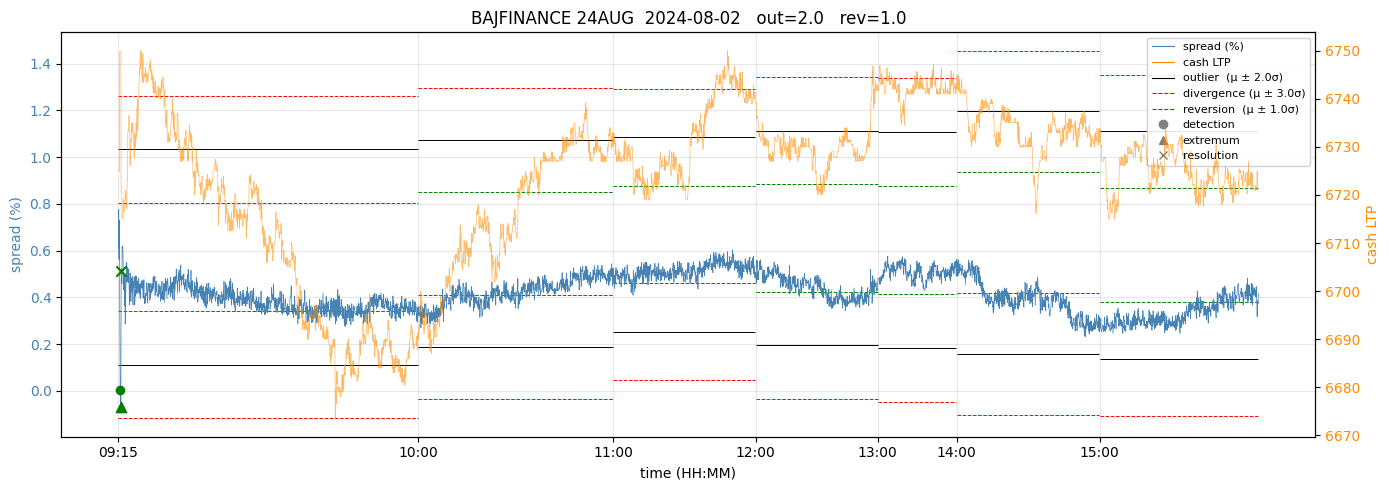

  24AUG: ticks=4800  events=1  classes={'reversion': 1}


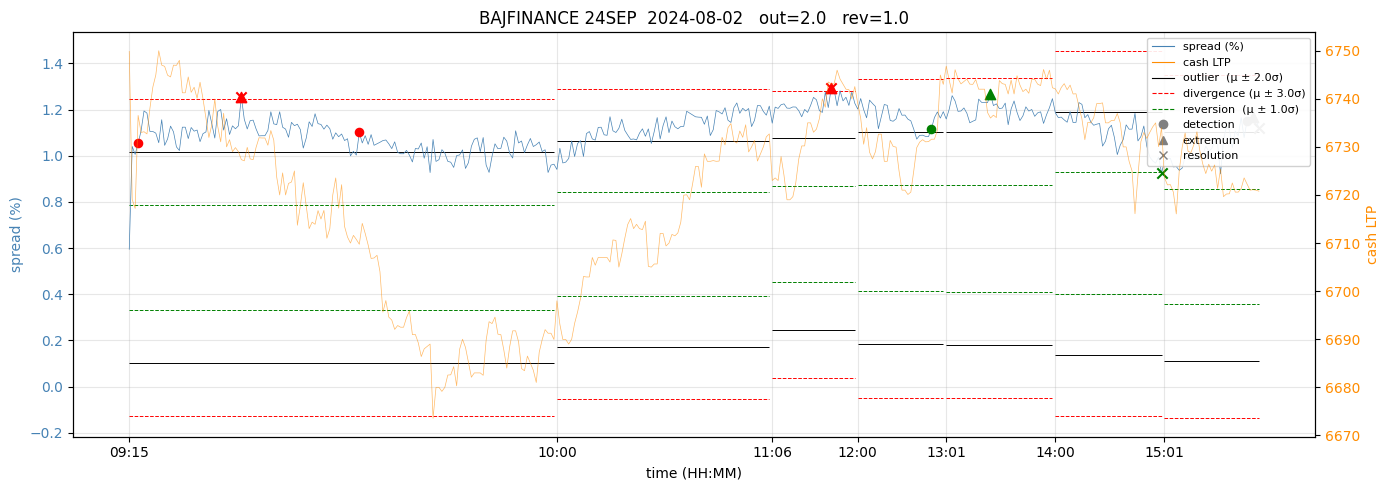

  24SEP: ticks=384  events=4  classes={'divergence': 2, 'reversion': 1, 'continuation': 1}


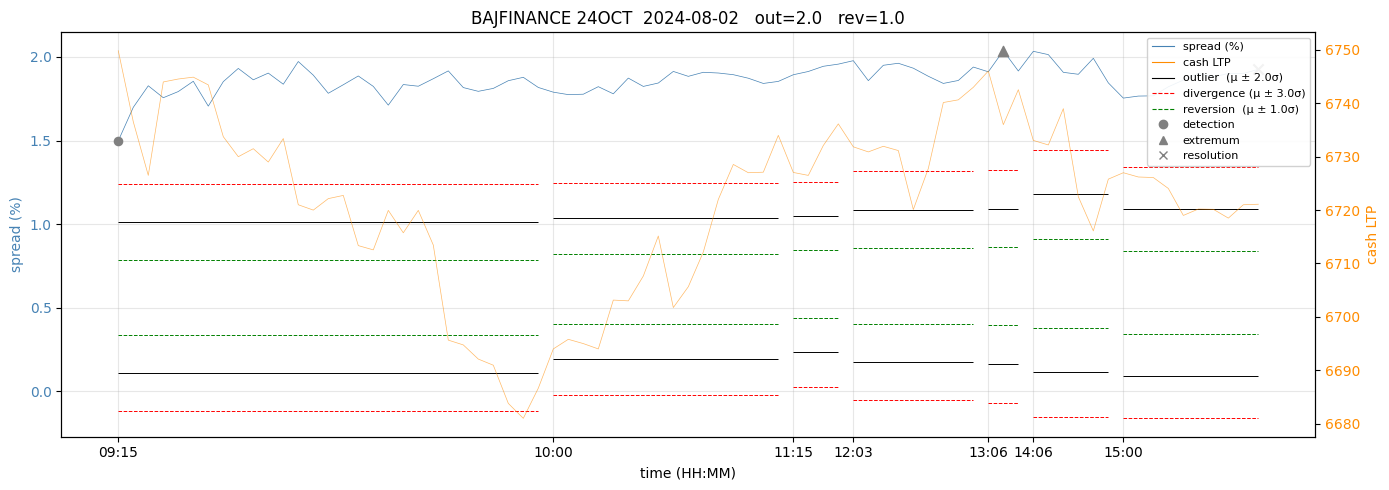

  24OCT: ticks=77  events=1  classes={'continuation': 1}


,det_idx,ext_idx,res_idx,side,klass,det_time,ext_time,res_time,det_spread,ext_spread,res_spread,det_z,ext_z,res_z,det_cash,bucket,dte,contract
0,8,11,12,-1,reversion,2024-08-02 09:15:08,2024-08-02 09:15:11,2024-08-02 09:15:13,0.002222,-0.068890,0.514091,-2.477222,-2.784212,-0.252170,6749.85,0,18,24AUG
1,3,38,38,1,divergence,2024-08-02 09:15:57,2024-08-02 09:24:15,2024-08-02 09:24:15,1.053952,1.254580,1.254580,2.160877,3.016282,3.016282,6736.55,0,18,24SEP
2,78,238,238,1,divergence,2024-08-02 09:37:55,2024-08-02 11:44:41,2024-08-02 11:44:41,1.100637,1.291691,1.291691,2.328421,3.019682,3.019682,6709.75,0,18,24SEP
3,272,292,350,1,reversion,2024-08-02 12:56:33,2024-08-02 13:16:14,2024-08-02 14:58:56,1.117862,1.266330,0.925156,2.045127,2.686142,0.981992,6731.60,3,18,24SEP
4,379,381,383,1,continuation,2024-08-02 15:28:43,2024-08-02 15:29:22,2024-08-02 15:29:59,1.152135,1.166476,1.118914,2.188726,2.245290,2.053051,6722.30,6,18,24SEP


In [14]:

log_df = run("BAJFINANCE", 2024, "AUG", 2,
             out_thresh=2.0, rev_thresh=1.0, min_ticks=3)
log_df.head()